[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# Train Soccer Pitch Keypoint Detector

---

[![Download Dataset](https://app.roboflow.com/images/download-dataset-badge.svg)](https://universe.roboflow.com/roboflow-jvuqo/football-field-detection-f07vi)

This notebook is based on the [How to Train a YOLOv8 Keypint Detection Model](https://github.com/roboflow/notebooks/blob/main/notebooks/train-yolov8-keypoint.ipynb) notebook from the [roboflow/notebooks](https://github.com/roboflow/notebooks) repository.

## Configure API keys

- Open your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [18]:
import shutil
shutil.rmtree('/content/drive')

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
import os
assert os.path.ismount('/content/drive'), "STOP — Drive not mounted!"
print("Drive mounted successfully")

Drive mounted successfully


In [22]:
import os
HOME = os.getcwd()
print(HOME)

/content/datasets


## Install dependencies

In [3]:
!pip install -q ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 4.6 MB/s eta 0:00:00


## Imports

In [4]:
from roboflow import Roboflow
from google.colab import userdata
from IPython.display import Image

## Pull dataset

In [5]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

ROBOFLOW_API_KEY = userdata.get('Roboflow')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

project = rf.workspace("roboflow-jvuqo").project("football-field-detection-f07vi")
version = project.version(18)
dataset = version.download("yolov8")

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to football-field-detection-18 in yolov8:: 100%|██████████| 639/639 [00:00<00:00, 3933.93it/s]


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


**NOTE:** Update `data.yaml` structure to align with the latest requirements of the `ultralytics` package.

In [6]:
!sed -i 's|\(train: \).*|\1../train/images|' {dataset.location}/data.yaml
!sed -i 's|\(val: \).*|\1../valid/images|' {dataset.location}/data.yaml

## Custom training

mount on google drive

In [7]:
import os

drive_project_path_keypoints = "/content/drive/MyDrive/yolov8_project/keypoint_detection"
os.makedirs(drive_project_path_keypoints, exist_ok=True)

In [23]:
%cd {HOME}

#!yolo task=pose mode=train model=yolov8x-pose.pt data={dataset.location}/data.yaml batch=16 epochs=100 imgsz=640 mosaic=0.0 plots=True
#!yolo task=pose mode=train model=yolov8x-pose.pt data={dataset.location}/data.yaml batch=6 epochs=50 imgsz=640 plots=True project={drive_project_path_keypoints} name="trains" exist_ok=True save_period=5
!yolo task=pose mode=train model=yolov8n-pose.pt data={dataset.location}/data.yaml batch=4 epochs=20 imgsz=416 plots=True project={drive_project_path_keypoints} name="trains" exist_ok=True save_period=2

/content/datasets
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/football-field-detection-18/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-pose.pt, momentum=0.937, mosaic=1.0, multi_

#Resume training if disconnected mid_run

In [12]:
!yolo task=pose mode=train resume=True model={drive_project_path_keypoints}/trains/weights/last.pt

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/cfg/__init__.py", line 1093, in entrypoint
    model = YOLO(model, task=task)
            ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/models/yolo/model.py", line 80, in __init__
    super().__init__(model=model, task=task, verbose=verbose)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 132, in __init__
    self._load(model, task=task)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 248, in _load
    self.model, self.ckpt = load_checkpoint(weights)
                            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/nn/tasks.py", line 1897, in load_checkpoint
    ckpt, weight = torch_safe_load(weight)  # load ckpt
                   ^^^^^^^^

#Verify checkpoints are landing in drive

In [26]:
#!ls {HOME}/runs/pose/train/
!ls {drive_project_path_keypoints}/trains

args.yaml			 PoseP_curve.png     train_batch641.jpg
BoxF1_curve.png			 PosePR_curve.png    train_batch642.jpg
BoxP_curve.png			 PoseR_curve.png     val_batch0_labels.jpg
BoxPR_curve.png			 results.csv	     val_batch0_pred.jpg
BoxR_curve.png			 results.png	     val_batch1_labels.jpg
confusion_matrix_normalized.png  train_batch0.jpg    val_batch1_pred.jpg
confusion_matrix.png		 train_batch1.jpg    val_batch2_labels.jpg
labels.jpg			 train_batch2.jpg    val_batch2_pred.jpg
PoseF1_curve.png		 train_batch640.jpg  weights


/content/datasets


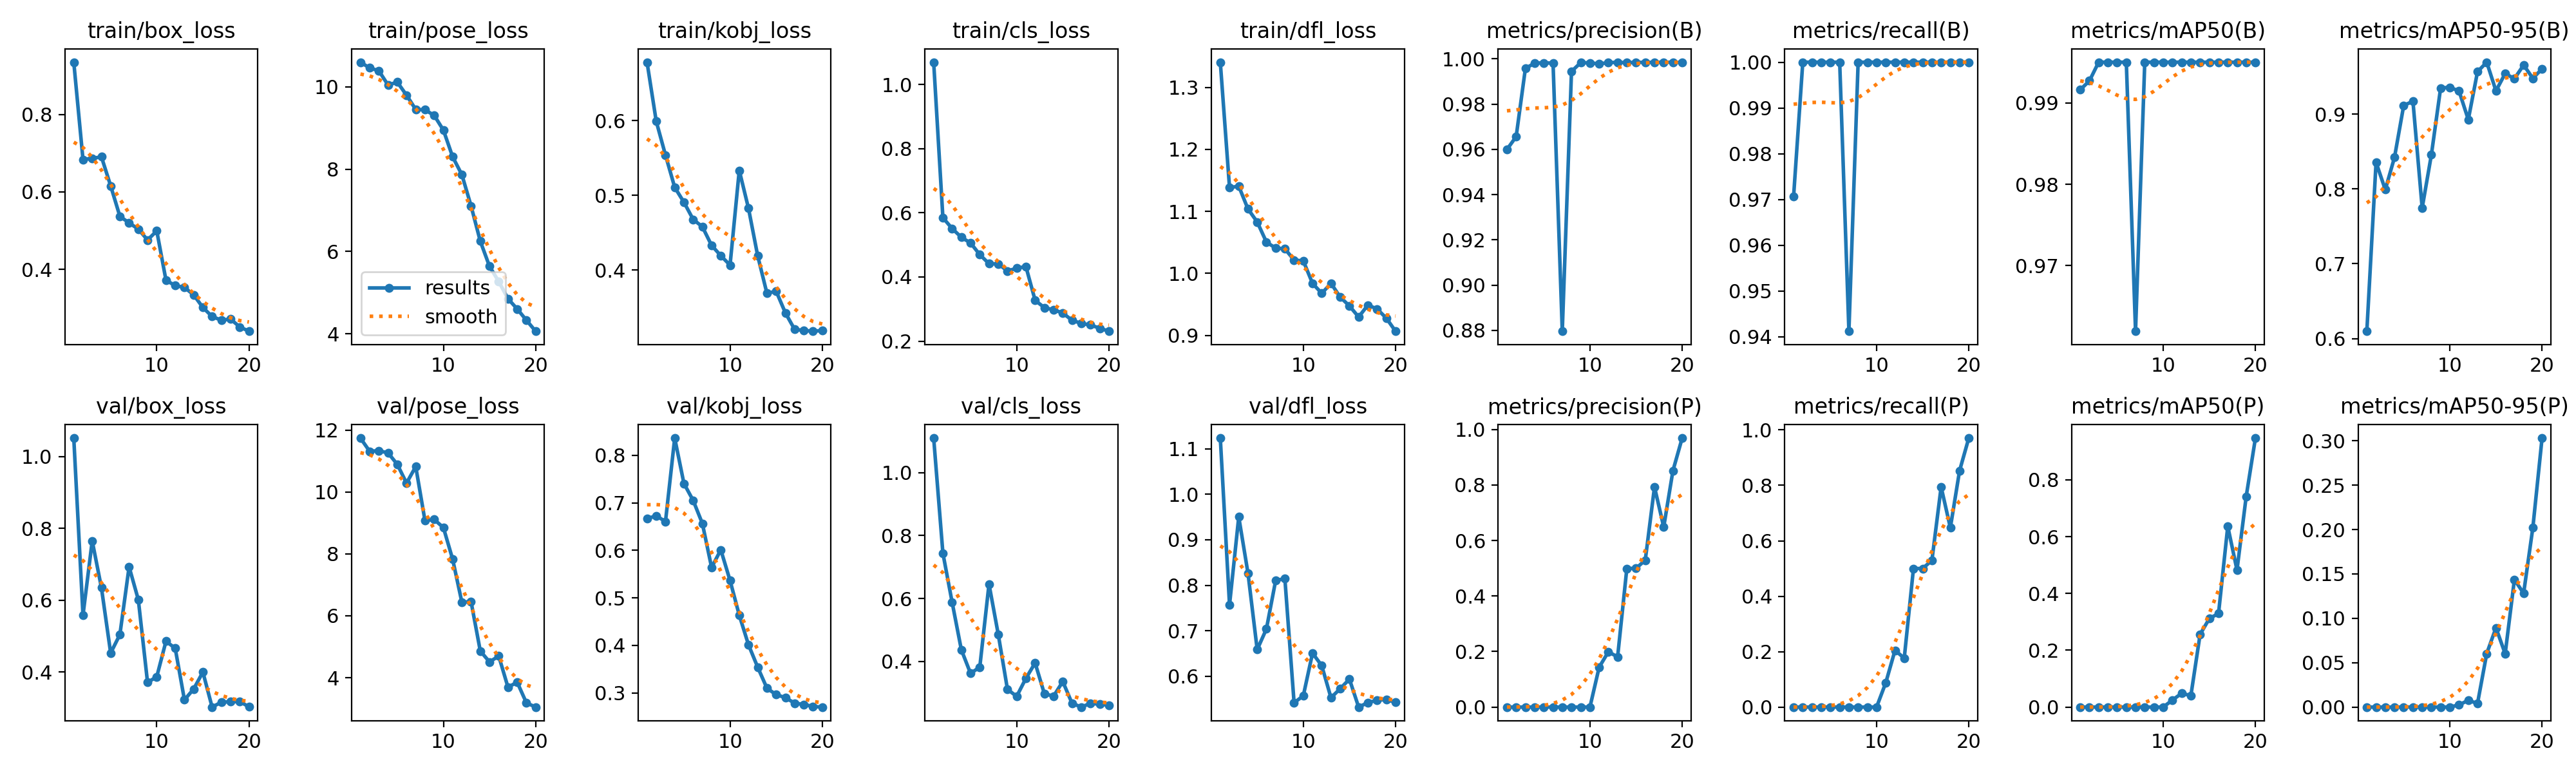

In [27]:
%cd {HOME}
Image(filename=f'{drive_project_path_keypoints}/trains/results.png', width=600)

/content/datasets


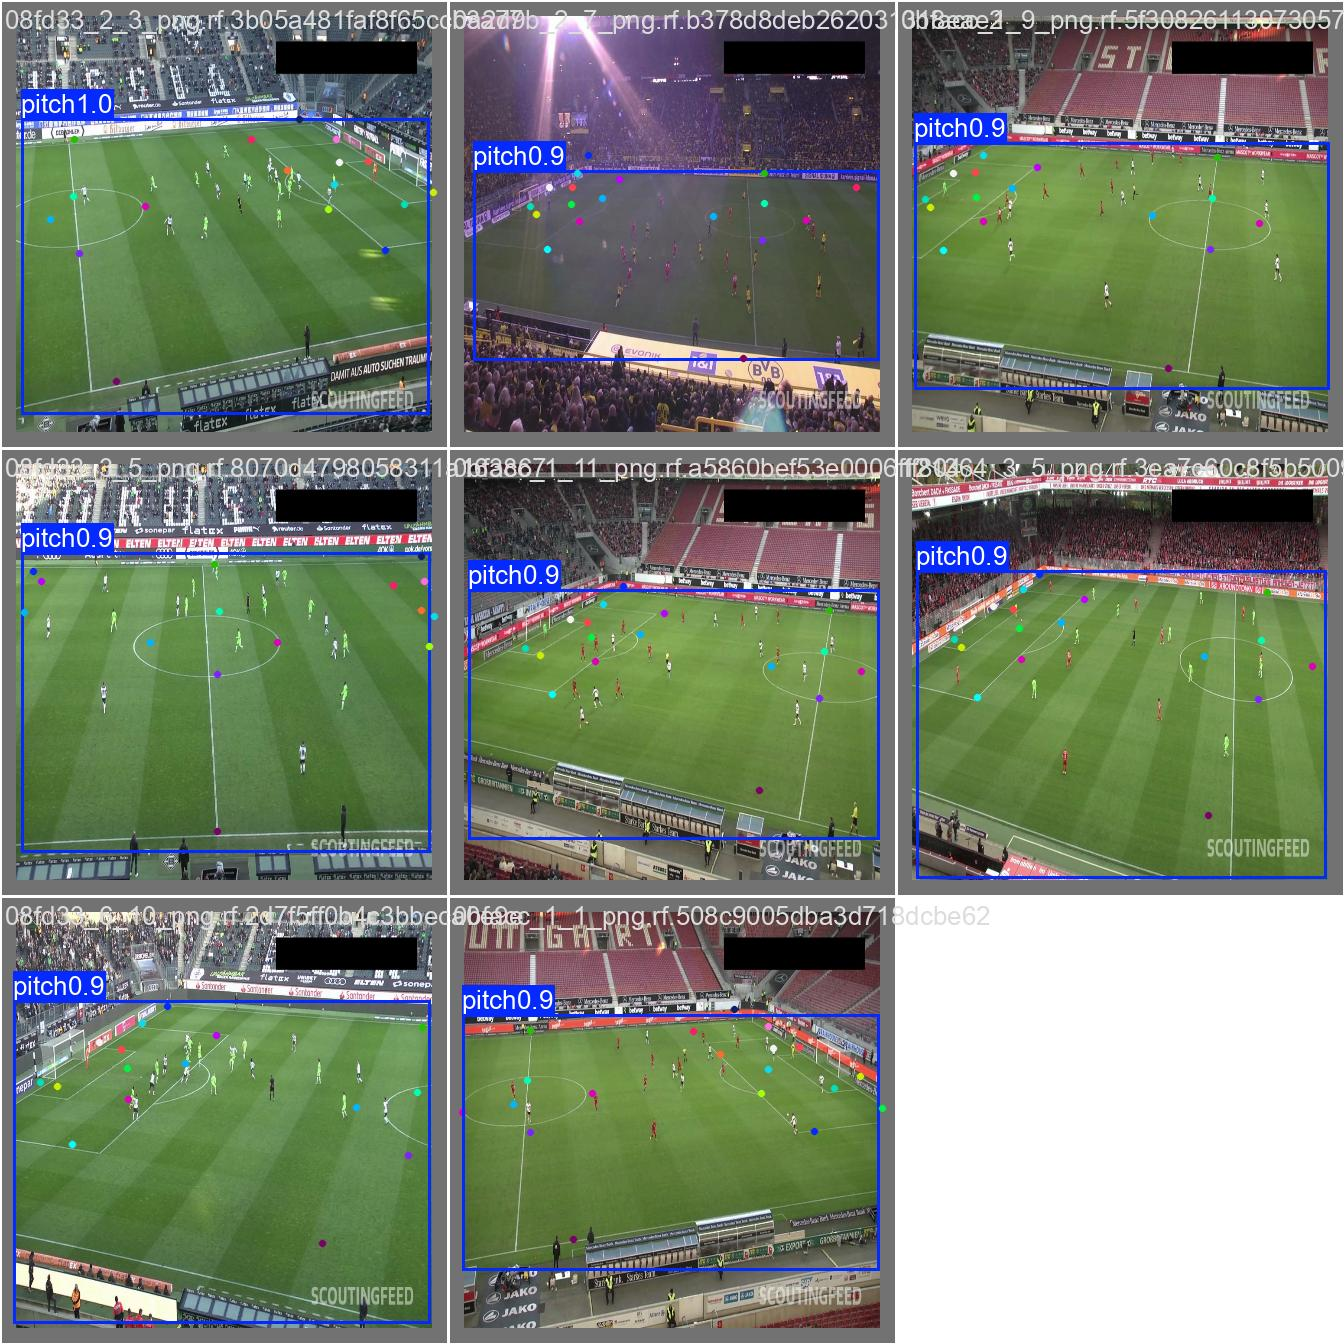

In [28]:
%cd {HOME}
Image(filename=f'{drive_project_path_keypoints}/trains/val_batch0_pred.jpg', width=600)

## Validate custom model

In [29]:
%cd {HOME}

!yolo task=pose mode=val model={drive_project_path_keypoints}/trains/weights/best.pt data={dataset.location}/data.yaml

/content/datasets
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8n-pose summary (fused): 82 layers, 3,670,259 parameters, 0 gradients, 10.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2428.2±1212.4 MB/s, size: 125.0 KB)
val: Scanning /content/datasets/football-field-detection-18/valid/labels.cache... 34 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 34/34 5.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.4s/it 7.3s
                   all         34         34      0.998          1      0.995      0.961      0.969      0.971      0.947      0.303
Speed: 6.8ms preprocess, 184.5ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /content/datasets/runs/pose/val
💡 Learn more at https://docs.ultralytics.com/modes/val


## Deploy model on Roboflow

In [30]:
#project.version(dataset.version).deploy(model_type="yolov8-pose", model_path=f"{HOME}/runs/pose/train/")
project.version(dataset.version).deploy(model_type="yolov8-pose", model_path=f"{drive_project_path_keypoints}/trains/")

ultralytics==8.0.196 is recommended for this upload, but ultralytics 8.4.115 is installed. Retry with allow_dependency_mismatch=True to package with the installed version, or `pip install ultralytics==8.0.196`.
Would you like to continue anyway? y/n: y
ultralytics==8.0.196 is recommended for this upload, but ultralytics 8.4.115 is installed.
Inferred model size 'yolov8n' from the checkpoint architecture (model_type was 'yolov8-pose').
An error occured when getting the model upload URL: 404 Client Error: Not Found for url: https://api.roboflow.com/roboflow-jvuqo/football-field-detection-f07vi/18/uploadModel?api_key=BVsY1jgpRSprqMqvAQ5v&modelType=yolov8n-pose&nocache=true
